# Energy Attribution Visualizations for HPC Libraries

This notebook produces publication-quality figures showing how GPU energy is distributed across **libraries** (rocBLAS, HPL routines, MPI, HIP/system) and the **functions** within them. MPI communication phases — during which the GPU idles — are filtered out to focus on actual compute energy.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns
from ampere import Ensemble, MetricConfig, MetricType, connect, ak, set_backend, DataFrame
set_backend('pandas')
# -- Publication style --
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

connect(server="localhost", port=5555)

    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          

Client Version: v2025.07.03+64.gd6838bfbe
Pandas backend active — skipping Arkouda connection.


In [2]:
# ── Load traces ──────────────────────────────────────────────
configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def my_hpc_topology(metric_name, ranks):
    if 'device=4' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 0', 'MPI Rank 1']]
    if 'device=2' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 2', 'MPI Rank 3']]
    if 'device=6' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 4', 'MPI Rank 5']]
    if 'device=0' in metric_name: return [r for r in ranks if r.name in ['MPI Rank 6', 'MPI Rank 7']]
    return ranks

ranks = [f"MPI Rank {i}" for i in range(8)]
topo  = {"Node0": ranks}
ensemble = Ensemble.from_trace_paths(["./hpl-with-wrapper-trace"], topo, configs)

Loading Runs:   0%|          | 0/1 [00:00<?, ?it/s]

Loading Runs: 100%|██████████| 1/1 [00:09<00:00,  9.06s/it]


In [3]:
# ── Attribution: energy (Joules) and power (W) per function call ──
devices = [
    "A2rocm_smi:::energy_count:device=0",
    "A2rocm_smi:::energy_count:device=2",
    "A2rocm_smi:::energy_count:device=4",
    "A2rocm_smi:::energy_count:device=6",
]

df_joules = DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, strategy='exclusive')
    for m in devices
])

df_power = DataFrame.concat([
    ensemble.attribute(m, topology_resolver=my_hpc_topology, output_mode='rate', strategy='exclusive')
    for m in devices
])

time_profile = ensemble.time_profile(topology_resolver=my_hpc_topology, strategy='exclusive')

# Convert to pandas for plotting
energy  = df_joules.to_pandas()
power   = df_power.to_pandas()
timep   = time_profile.to_pandas()

# Compute duration
energy['Duration'] = energy['End Time'] - energy['Start Time']
power['Duration']  = power['End Time']  - power['Start Time']

print(f"Total attributed energy calls: {len(energy):,}")
print(f"Total energy: {energy['Value'].sum():,.1f} J")

Attributing 'A2rocm_smi:::energy_count:device=0' (pandas backend)...


100%|██████████| 1/1 [00:01<00:00,  1.03s/it]


Attributing 'A2rocm_smi:::energy_count:device=2' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


Attributing 'A2rocm_smi:::energy_count:device=4' (pandas backend)...


...

Attributing 'A2rocm_smi:::energy_count:device=6' (pandas backend)...


100%|██████████| 1/1 [00:00<00:00,  1.16it/s]


Profiling time (pandas backend)...


100%|██████████| 1/1 [00:07<00:00,  7.72s/it]


Total attributed energy calls: 6,300,954
Total energy: 160,345.0 J


In [4]:
# ── Classify every function into a library ───────────────────
def classify_library(name: str) -> str:
    """Map a function name to its parent library / category."""
    n = name.lower()
    if n.startswith('mpi_'):          return 'MPI'
    if 'rocblas' in n:                return 'rocBLAS'
    if 'rocsolver' in n:             return 'rocSOLVER'
    if n.startswith('hip') or 'hipmalloc' in n or 'hipcheck' in n: return 'HIP Runtime'
    if 'devicemalloc' in n or 'hostmalloc' in n:                   return 'HIP Runtime'
    if n.startswith('hpl_'):          return 'HPL'
    return 'Other'

def short_name(name: str) -> str:
    """Trim C++ signature to just the function name."""
    paren = name.find('(')
    return name[:paren] if paren != -1 else name

energy['Library']   = energy['Name'].apply(classify_library)
energy['ShortName'] = energy['Name'].apply(short_name)
power['Library']    = power['Name'].apply(classify_library)
power['ShortName']  = power['Name'].apply(short_name)
timep['Library']    = timep['Name'].apply(classify_library)
timep['ShortName']  = timep['Name'].apply(short_name)

# ── Filter out MPI (GPU-idle) calls ─────────────────────────
# MPI functions represent communication phases where the GPU is idling
# (latency hiding is disabled for these runs), so they add noise.
compute_energy = energy[energy['Library'] != 'MPI'].copy()
compute_power  = power[power['Library']  != 'MPI'].copy()
compute_time   = timep[timep['Library']  != 'MPI'].copy()

# Also filter out tiny-duration noise (< 1 ms)
MIN_DUR = 1e-3
compute_energy_sig = compute_energy[compute_energy['Duration'] >= MIN_DUR].copy()
compute_power_sig  = compute_power[compute_power['Duration']   >= MIN_DUR].copy()

# ── Palette ──────────────────────────────────────────────────
LIB_PALETTE = {
    'rocBLAS':     '#1b9e77',
    'rocSOLVER':   '#d95f02',
    'HPL':         '#7570b3',
    'HIP Runtime': '#e7298a',
    'MPI':         '#bdbdbd',
    'Other':       '#66a61e',
}

print("Library breakdown (energy, all calls):")
print(energy.groupby('Library')['Value'].sum().sort_values(ascending=False).to_string())
print(f"\nAfter filtering MPI + <1ms: {len(compute_energy_sig):,} calls")

Library breakdown (energy, all calls):
Library
rocBLAS        127243.052349
MPI             22644.579670
HPL             10456.399282
HIP Runtime         0.742053
Other               0.244825

After filtering MPI + <1ms: 46,274 calls


## Figure 1 — Nested Donut: Library and Function Energy Breakdown

A two-ring donut chart. The **inner ring** shows energy share by library; the **outer ring** breaks each library into its constituent functions. This replaces the flat heatmap with a hierarchical view that immediately conveys both the macro (library) and micro (function) picture.

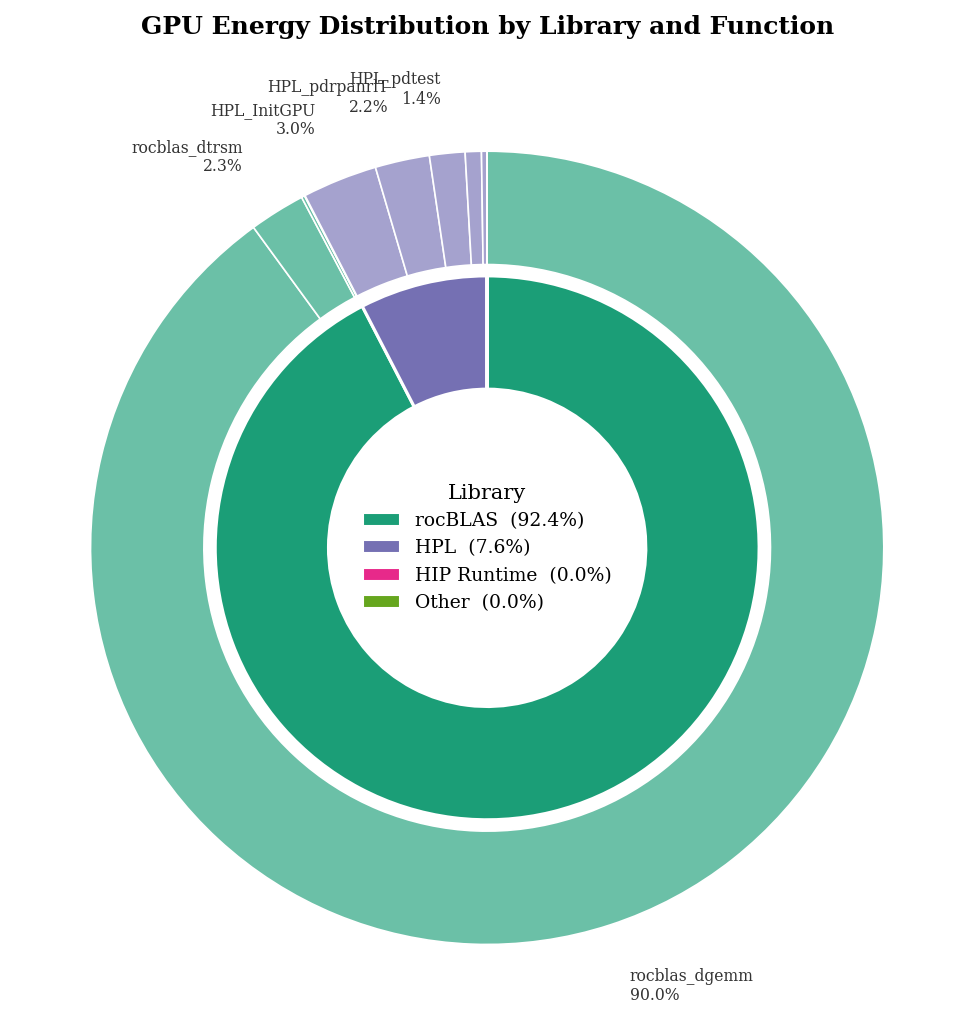

In [5]:
# ── Fig 1: Nested donut — Library → Function energy hierarchy ──

# Aggregate energy per library
lib_energy = compute_energy.groupby('Library')['Value'].sum().sort_values(ascending=False)
lib_order  = lib_energy.index.tolist()

# Aggregate energy per (library, function)
func_energy = (compute_energy.groupby(['Library', 'ShortName'])['Value']
               .sum().reset_index()
               .sort_values(['Library', 'Value'], ascending=[True, False]))

# For readability, keep top 4 functions per library, lump rest into "other"
outer_labels, outer_vals, outer_colors = [], [], []
for lib in lib_order:
    sub = func_energy[func_energy['Library'] == lib].copy()
    top = sub.head(4)
    rest_val = sub.iloc[4:]['Value'].sum() if len(sub) > 4 else 0
    for _, row in top.iterrows():
        outer_labels.append(row['ShortName'])
        outer_vals.append(row['Value'])
        outer_colors.append(LIB_PALETTE[lib])
    if rest_val > 0:
        outer_labels.append(f'other {lib}')
        outer_vals.append(rest_val)
        outer_colors.append(LIB_PALETTE[lib])

# Lighten outer ring colors for visual separation
def lighten(hex_color, factor=0.35):
    rgb = mcolors.to_rgb(hex_color)
    return tuple(c + (1 - c) * factor for c in rgb)

outer_colors_light = [lighten(c) for c in outer_colors]

# ── Plot ──
fig, ax = plt.subplots(figsize=(7, 7))

# Inner ring (libraries)
inner_colors = [LIB_PALETTE[l] for l in lib_order]
wedges_inner, texts_inner = ax.pie(
    lib_energy.values, labels=None, colors=inner_colors,
    radius=0.72, wedgeprops=dict(width=0.30, edgecolor='white', linewidth=1.5),
    startangle=90, counterclock=False
)

# Outer ring (functions)
wedges_outer, texts_outer = ax.pie(
    outer_vals, labels=None, colors=outer_colors_light,
    radius=1.05, wedgeprops=dict(width=0.30, edgecolor='white', linewidth=0.8),
    startangle=90, counterclock=False
)

# Annotate outer wedges (only those > 3% of total)
total = sum(outer_vals)
for wedge, label, val in zip(wedges_outer, outer_labels, outer_vals):
    if val / total < 0.01:
        continue
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 1.22 * np.cos(np.radians(angle))
    y = 1.22 * np.sin(np.radians(angle))
    ha = 'left' if x >= 0 else 'right'
    pct = val / total * 100
    ax.annotate(f'{label}\n{pct:.1f}%', xy=(x, y), fontsize=7.5,
                ha=ha, va='center', color='#333333')

# Inner ring legend
legend_handles = [mpatches.Patch(facecolor=LIB_PALETTE[l], edgecolor='white', label=f'{l}  ({lib_energy[l]/total*100:.1f}%)')
                  for l in lib_order]
ax.legend(handles=legend_handles, loc='center', frameon=False, fontsize=9,
          title='Library', title_fontsize=10)

ax.set_title('GPU Energy Distribution by Library and Function', pad=20, fontweight='bold')
fig.tight_layout()
plt.savefig('fig1_nested_donut.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Energy vs. Time: Where Does the Power Go?

A paired horizontal lollipop chart comparing each library's share of **total energy** (left) versus its share of **total wall-clock time** (right). Libraries that consume disproportionately more energy than time are less energy-efficient — the visual gap between the two dots makes this immediately obvious.

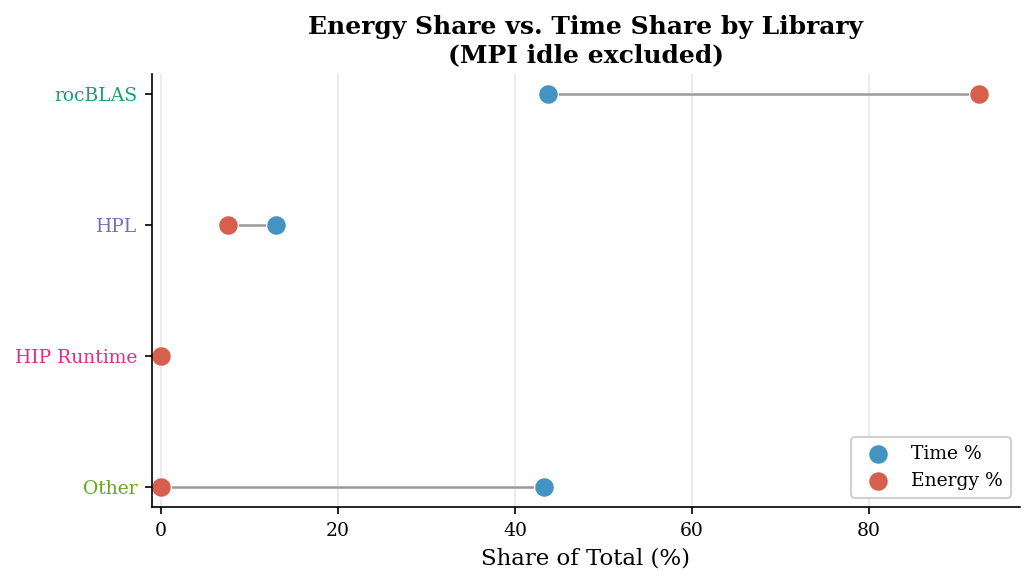

In [6]:
# ── Fig 2: Paired lollipop — Energy fraction vs Time fraction per library ──

# Energy fractions (excluding MPI)
e_by_lib = compute_energy.groupby('Library')['Value'].sum()
e_frac   = (e_by_lib / e_by_lib.sum() * 100).sort_values(ascending=True)

# Time fractions (excluding MPI)
t_by_lib = compute_time.groupby('ShortName')['Value'].sum()
# Re-classify time profile names into libraries
t_lib = compute_time.copy()
t_by_lib = t_lib.groupby('Library')['Value'].sum()
t_frac   = (t_by_lib / t_by_lib.sum() * 100).reindex(e_frac.index, fill_value=0)

libs = e_frac.index.tolist()
y_pos = np.arange(len(libs))

fig, ax = plt.subplots(figsize=(7, 4))

# Connecting lines
for i, lib in enumerate(libs):
    e, t = e_frac[lib], t_frac[lib]
    ax.plot([t, e], [i, i], color='#999999', linewidth=1.2, zorder=1)

# Time dots
ax.scatter(t_frac.values, y_pos, s=90, color='#4393c3', zorder=2,
           edgecolors='white', linewidths=0.6, label='Time %')
# Energy dots
ax.scatter(e_frac.values, y_pos, s=90, color='#d6604d', zorder=2,
           edgecolors='white', linewidths=0.6, label='Energy %')

# Library labels on the y-axis, colored by library
ax.set_yticks(y_pos)
ax.set_yticklabels(libs)
for i, lib in enumerate(libs):
    ax.get_yticklabels()[i].set_color(LIB_PALETTE.get(lib, '#333'))

ax.set_xlabel('Share of Total (%)')
ax.set_title('Energy Share vs. Time Share by Library\n(MPI idle excluded)', fontweight='bold')
ax.legend(loc='lower right', frameon=True, framealpha=0.9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(left=-1)

fig.tight_layout()
plt.savefig('fig2_energy_vs_time.pdf', bbox_inches='tight')
plt.show()

## Figure 3 — Ridgeline Plot: Per-Call Power Distribution by Function

A ridgeline (joy) plot showing the **distribution of instantaneous power draw** across individual invocations of each top function. Overlapping density curves reveal whether a function has consistent power behavior or high variance across calls — crucial for understanding energy predictability.

/var/folders/3h/cbgps36j7q58_ghglykw4ggw0000gn/T/ipykernel_41818/2623341865.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


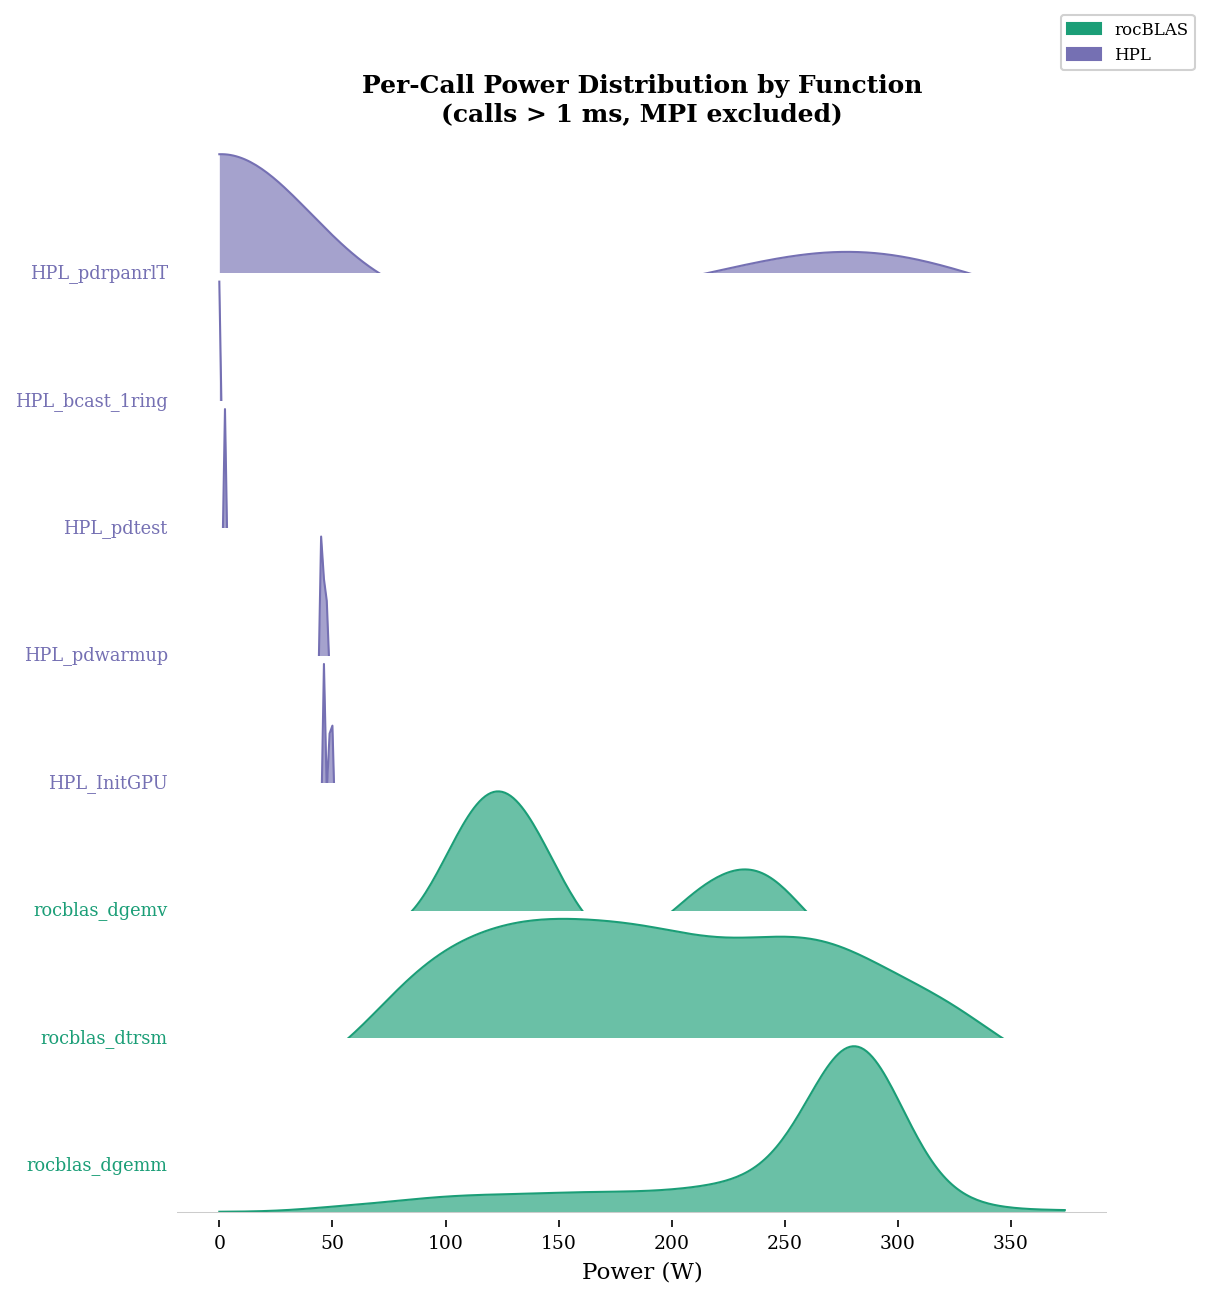

In [7]:
# ── Fig 3: Ridgeline — Power distribution per function ───────

from scipy.stats import gaussian_kde

# Pick top functions by total energy (significant calls only)
top_funcs_e = (compute_energy_sig.groupby('ShortName')['Value'].sum()
               .sort_values(ascending=False).head(8).index.tolist())

# Get power data for these functions
ridge_data = compute_power_sig[compute_power_sig['ShortName'].isin(top_funcs_e)].copy()
# Map to library for coloring
ridge_data['Library'] = ridge_data['Name'].apply(classify_library)

# Order functions by median power (top = highest)
func_order = (ridge_data.groupby('ShortName')['Value']
              .median().reindex(top_funcs_e).sort_values(ascending=True).index.tolist())

n_funcs = len(func_order)
fig, axes = plt.subplots(n_funcs, 1, figsize=(8, 1.1 * n_funcs + 0.5),
                         sharex=True, gridspec_kw={'hspace': -0.3})

# Global x range
all_vals = ridge_data['Value'].dropna()
x_grid = np.linspace(all_vals.quantile(0.01), all_vals.quantile(0.99), 300)

for i, func in enumerate(func_order):
    ax = axes[i]
    vals = ridge_data[ridge_data['ShortName'] == func]['Value'].dropna().values
    lib  = ridge_data[ridge_data['ShortName'] == func]['Library'].iloc[0]
    color = LIB_PALETTE.get(lib, '#888888')

    if len(vals) > 3:
        try:
            kde = gaussian_kde(vals, bw_method=0.3)
            density = kde(x_grid)
            density = density / density.max()  # normalize height to [0,1]
        except np.linalg.LinAlgError:
            density = np.zeros_like(x_grid)
    else:
        density = np.zeros_like(x_grid)

    ax.fill_between(x_grid, density, alpha=0.65, color=color, linewidth=0)
    ax.plot(x_grid, density, color=color, linewidth=1.0)
    ax.axhline(0, color='#cccccc', linewidth=0.5)

    # Label
    ax.set_yticks([])
    ax.text(-0.01, 0.3, func, transform=ax.transAxes, ha='right', va='center',
            fontsize=8.5, fontweight='medium', color=color)

    # Clean spines
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[-1].set_xlabel('Power (W)')
axes[0].set_title('Per-Call Power Distribution by Function\n(calls > 1 ms, MPI excluded)',
                   fontweight='bold', pad=12)

# Library legend
legend_handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l)
                  for l in ['rocBLAS', 'rocSOLVER', 'HPL', 'HIP Runtime', 'Other']
                  if l in ridge_data['Library'].values]
fig.legend(handles=legend_handles, loc='upper right', frameon=True, framealpha=0.9,
           fontsize=8, bbox_to_anchor=(0.98, 0.98))

fig.tight_layout()
plt.savefig('fig3_ridgeline_power.pdf', bbox_inches='tight')
plt.show()

## Figure 4 — Temporal Energy Heatmap (Compute Only)

A rank-vs-time heatmap showing **energy intensity** across the execution timeline. Each row is one MPI rank; each column is a time bin. Only compute phases are shown (MPI idle bins are masked to white). This reveals temporal patterns — initialization spikes, steady-state compute, and load imbalance across ranks.

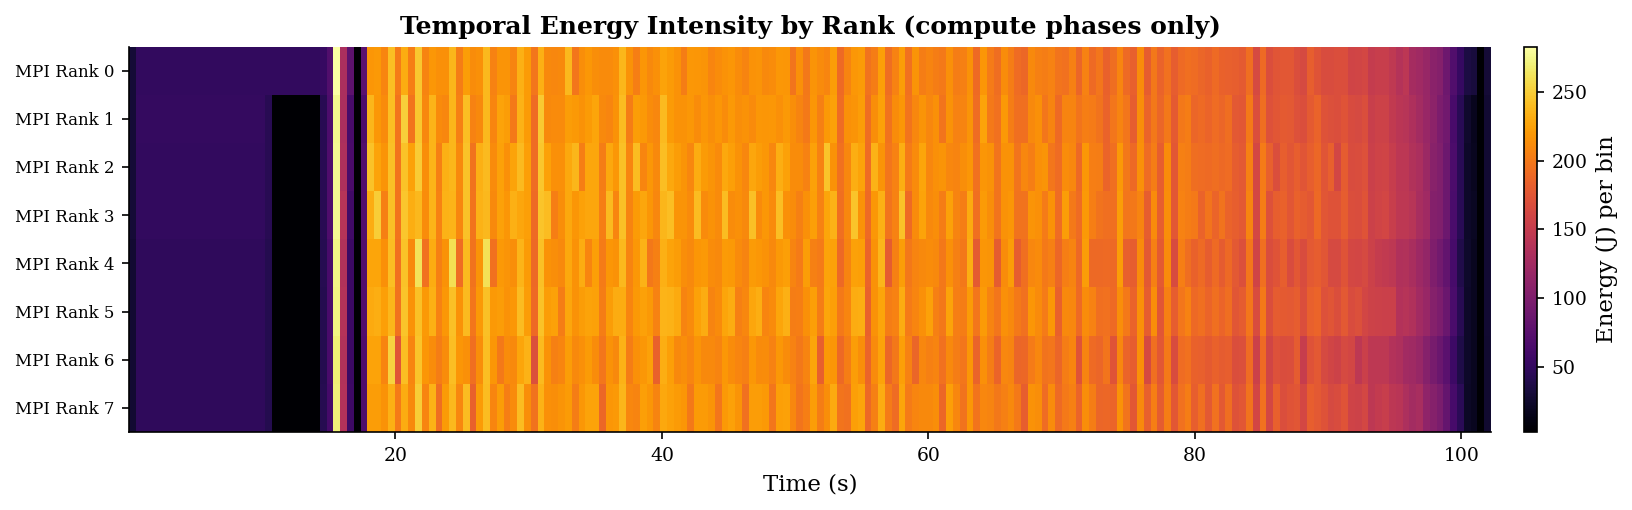

In [8]:
# ── Fig 4: Temporal energy heatmap — Rank × Time (compute only) ──

N_BINS = 200
t_min = compute_energy['Start Time'].min()
t_max = compute_energy['End Time'].max()
bin_edges = np.linspace(t_min, t_max, N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

rank_names = sorted(compute_energy['Rank'].unique())
heat = np.full((len(rank_names), N_BINS), np.nan)

for ri, rname in enumerate(rank_names):
    rsub = compute_energy[compute_energy['Rank'] == rname]
    for _, row in rsub.iterrows():
        s, e, v = row['Start Time'], row['End Time'], row['Value']
        # Find overlapping bins
        i_start = np.searchsorted(bin_edges, s, side='right') - 1
        i_end   = np.searchsorted(bin_edges, e, side='left')
        i_start = max(i_start, 0)
        i_end   = min(i_end, N_BINS)
        for bi in range(i_start, i_end):
            # Proportional overlap
            overlap = min(e, bin_edges[bi+1]) - max(s, bin_edges[bi])
            bin_width = bin_edges[bi+1] - bin_edges[bi]
            frac = overlap / bin_width if bin_width > 0 else 0
            contrib = v * frac / (e - s) if (e - s) > 0 else 0
            heat[ri, bi] = np.nansum([heat[ri, bi], contrib]) if not np.isnan(heat[ri, bi]) else contrib

# Mask bins with no compute (they stay as NaN → white)
masked_heat = np.ma.masked_invalid(heat)

fig, ax = plt.subplots(figsize=(12, 3.5))
cmap = plt.cm.inferno.copy()
cmap.set_bad('white')

im = ax.pcolormesh(bin_edges, np.arange(len(rank_names) + 1), masked_heat,
                   cmap=cmap, shading='flat')

ax.set_yticks(np.arange(len(rank_names)) + 0.5)
ax.set_yticklabels(rank_names, fontsize=8)
ax.set_xlabel('Time (s)')
ax.set_title('Temporal Energy Intensity by Rank (compute phases only)', fontweight='bold')
ax.invert_yaxis()

cbar = fig.colorbar(im, ax=ax, pad=0.02, aspect=30)
cbar.set_label('Energy (J) per bin')

fig.tight_layout()
plt.savefig('fig4_temporal_heatmap.pdf', bbox_inches='tight')
plt.show()

## Figure 5 — Stacked Horizontal Bar: Per-Rank Energy Breakdown by Library

Each bar is one MPI rank. The segments show how energy is partitioned across libraries for that rank. This replaces the raw-number heatmap with a proportional view that highlights load balance and library dominance per rank.

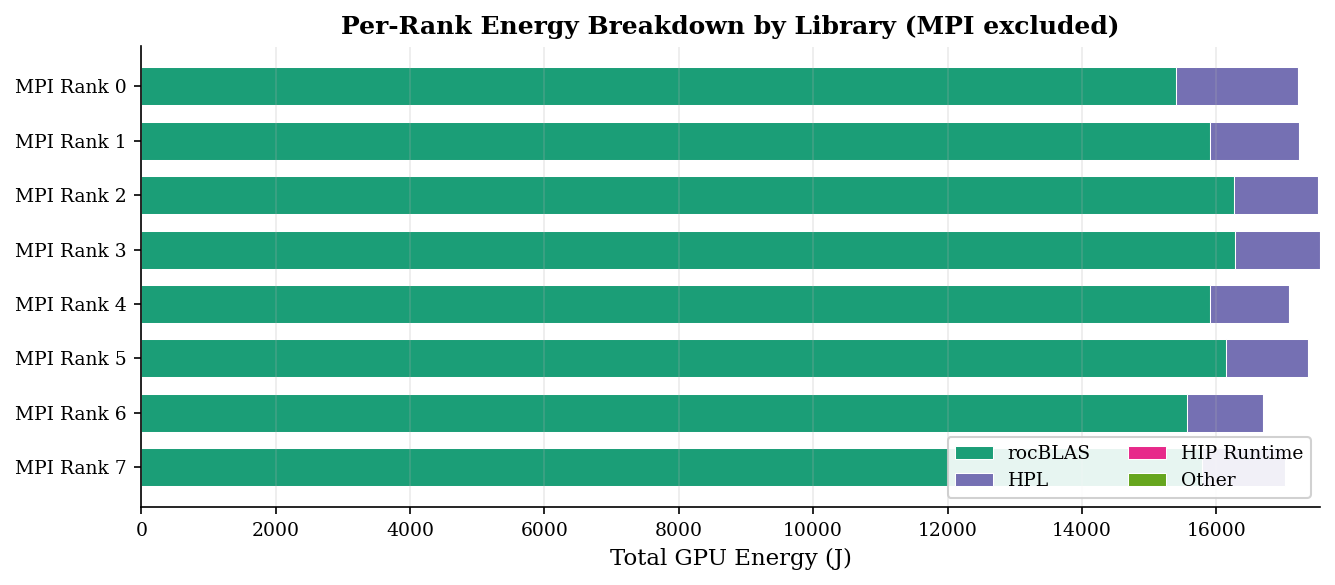

In [9]:
# ── Fig 5: Stacked horizontal bar — Per-rank library energy ──

pivot = (compute_energy
         .groupby(['Rank', 'Library'])['Value']
         .sum()
         .unstack(fill_value=0))

# Order libraries by total energy (largest at bottom of stack)
lib_totals = pivot.sum().sort_values(ascending=False)
pivot = pivot[lib_totals.index]
rank_order = sorted(pivot.index)
pivot = pivot.reindex(rank_order)

fig, ax = plt.subplots(figsize=(9, 4))

left = np.zeros(len(pivot))
for lib in pivot.columns:
    vals = pivot[lib].values
    color = LIB_PALETTE.get(lib, '#888')
    ax.barh(np.arange(len(pivot)), vals, left=left, color=color,
            edgecolor='white', linewidth=0.5, label=lib, height=0.7)
    left += vals

ax.set_yticks(np.arange(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel('Total GPU Energy (J)')
ax.set_title('Per-Rank Energy Breakdown by Library (MPI excluded)', fontweight='bold')
ax.legend(loc='lower right', frameon=True, framealpha=0.9, ncol=2)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.25)

fig.tight_layout()
plt.savefig('fig5_stacked_bar_ranks.pdf', bbox_inches='tight')
plt.show()

## Figure 6 — Bee Swarm: Energy per Call with Library Grouping

A strip/bee-swarm plot showing **every significant function call** as a single point, grouped by library. The x-axis is energy per call (log scale), the y-axis groups by library, and color encodes the specific function. This reveals both the distribution shape and outliers that averages would hide.

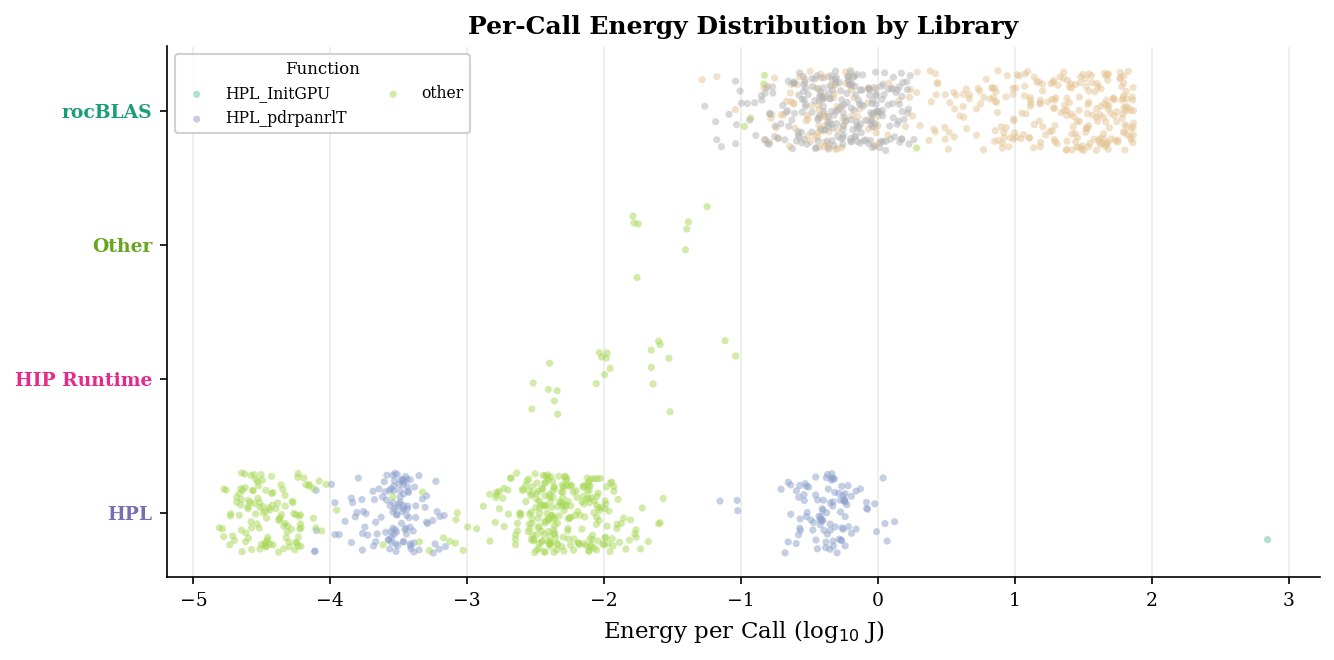

In [10]:
# ── Fig 6: Strip plot — Energy per call, grouped by library ──

# Use significant calls only
strip_df = compute_energy_sig[compute_energy_sig["Value"] > 0].copy()
strip_df["log_energy"] = np.log10(strip_df["Value"])

# Map each function to the top-N for labeling, rest become "other"
top_n_strip = 6
func_totals = strip_df.groupby("ShortName")["Value"].sum().sort_values(ascending=False)
top_funcs = func_totals.head(top_n_strip).index.tolist()
strip_df["FuncLabel"] = strip_df["ShortName"].where(strip_df["ShortName"].isin(top_funcs), "other")

# Order libraries by median energy
lib_median = strip_df.groupby("Library")["log_energy"].median().sort_values(ascending=True)
lib_plot_order = lib_median.index.tolist()

fig, ax = plt.subplots(figsize=(9, 4.5))

# Subsample if too many points (for visual clarity)
max_per_lib = 600
sampled = []
for lib in lib_plot_order:
    grp = strip_df[strip_df["Library"] == lib]
    sampled.append(grp.sample(n=min(len(grp), max_per_lib), random_state=42))
plot_df = pd.concat(sampled)

# Use a distinct colormap for function labels
func_labels_unique = sorted(plot_df["FuncLabel"].unique())
n_labels = len(func_labels_unique)
cmap_funcs = plt.cm.Set2 if n_labels <= 8 else plt.cm.tab20
func_colors = {f: cmap_funcs(i / max(n_labels - 1, 1)) for i, f in enumerate(func_labels_unique)}

for i, lib in enumerate(lib_plot_order):
    sub = plot_df[plot_df["Library"] == lib]
    # Jitter y
    jitter = np.random.default_rng(42).uniform(-0.3, 0.3, size=len(sub))
    for fl in func_labels_unique:
        mask = sub["FuncLabel"] == fl
        if mask.sum() == 0:
            continue
        ax.scatter(sub.loc[mask, "log_energy"], i + jitter[mask.values],
                   s=12, alpha=0.5, color=func_colors[fl],
                   edgecolors="none", label=fl if i == 0 else None)

ax.set_yticks(range(len(lib_plot_order)))
ax.set_yticklabels(lib_plot_order)
for j, lib in enumerate(lib_plot_order):
    ax.get_yticklabels()[j].set_color(LIB_PALETTE.get(lib, "#333"))
    ax.get_yticklabels()[j].set_fontweight("bold")

ax.set_xlabel("Energy per Call (log$_{10}$ J)")
ax.set_title("Per-Call Energy Distribution by Library", fontweight="bold")

# De-duplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper left",
          fontsize=7.5, frameon=True, framealpha=0.9, title="Function", title_fontsize=8, ncol=2)

ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.savefig("fig6_strip_energy.pdf", bbox_inches="tight")
plt.show()


## Figure 7 — Bubble Chart: Duration vs. Power vs. Total Energy

Each bubble is one function (aggregated across all ranks). The x-axis is total time spent, the y-axis is mean power draw, and bubble size encodes total energy consumed. Library color-coding ties it all together. This single chart answers: *which functions run longest, draw the most power, and consume the most energy?*

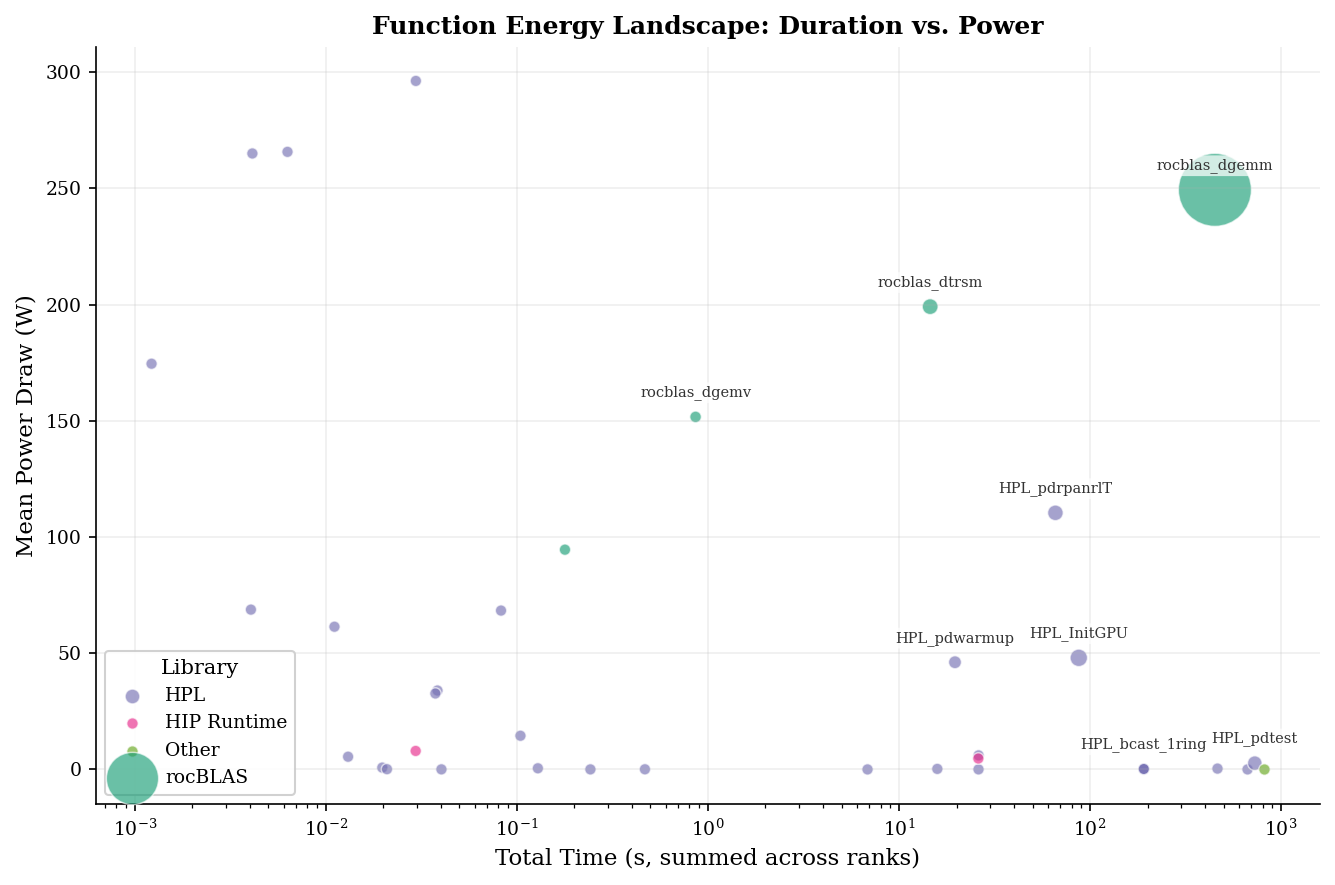

In [11]:
# ── Fig 7: Bubble chart — Duration × Power × Energy per function ──

# Aggregate per function (across all ranks)
func_agg = (compute_energy_sig.groupby('ShortName').agg(
    total_energy=('Value', 'sum'),
    total_time=('Duration', 'sum'),
    call_count=('Value', 'count'),
    library=('Library', 'first'),
).reset_index())

# Mean power from the power dataframe
power_agg = compute_power_sig.groupby('ShortName')['Value'].mean().rename('mean_power')
func_agg = func_agg.merge(power_agg, on='ShortName', how='left').dropna(subset=['mean_power'])

# Filter to functions with meaningful energy
func_agg = func_agg[func_agg['total_energy'] > func_agg['total_energy'].quantile(0.1)]

# Bubble size scaling
size_scale = func_agg['total_energy'] / func_agg['total_energy'].max() * 1200 + 30

fig, ax = plt.subplots(figsize=(9, 6))

for lib in func_agg['library'].unique():
    sub = func_agg[func_agg['library'] == lib]
    sizes = sub['total_energy'] / func_agg['total_energy'].max() * 1200 + 30
    ax.scatter(sub['total_time'], sub['mean_power'], s=sizes,
               color=LIB_PALETTE.get(lib, '#888'), alpha=0.65,
               edgecolors='white', linewidths=0.7, label=lib)

# Label the top functions
top_labels = func_agg.nlargest(8, 'total_energy')
for _, row in top_labels.iterrows():
    ax.annotate(row['ShortName'], (row['total_time'], row['mean_power']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points',
                color='#333333',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))

ax.set_xlabel('Total Time (s, summed across ranks)')
ax.set_ylabel('Mean Power Draw (W)')
ax.set_title('Function Energy Landscape: Duration vs. Power',
             fontweight='bold')
ax.legend(title='Library', frameon=True, framealpha=0.9)
ax.grid(alpha=0.2)

# Log scale if range is large
if func_agg['total_time'].max() / max(func_agg['total_time'].min(), 1e-9) > 100:
    ax.set_xscale('log')

fig.tight_layout()
plt.savefig('fig7_bubble_chart.pdf', bbox_inches='tight')
plt.show()

## Figure 8 — Temporal Stacked Area: Library Energy Over Time

A stacked area chart showing the **cumulative energy consumption rate by library** across the execution timeline. This reveals the temporal phasing of the application — initialization, factorization, solve — and which library dominates energy in each phase.

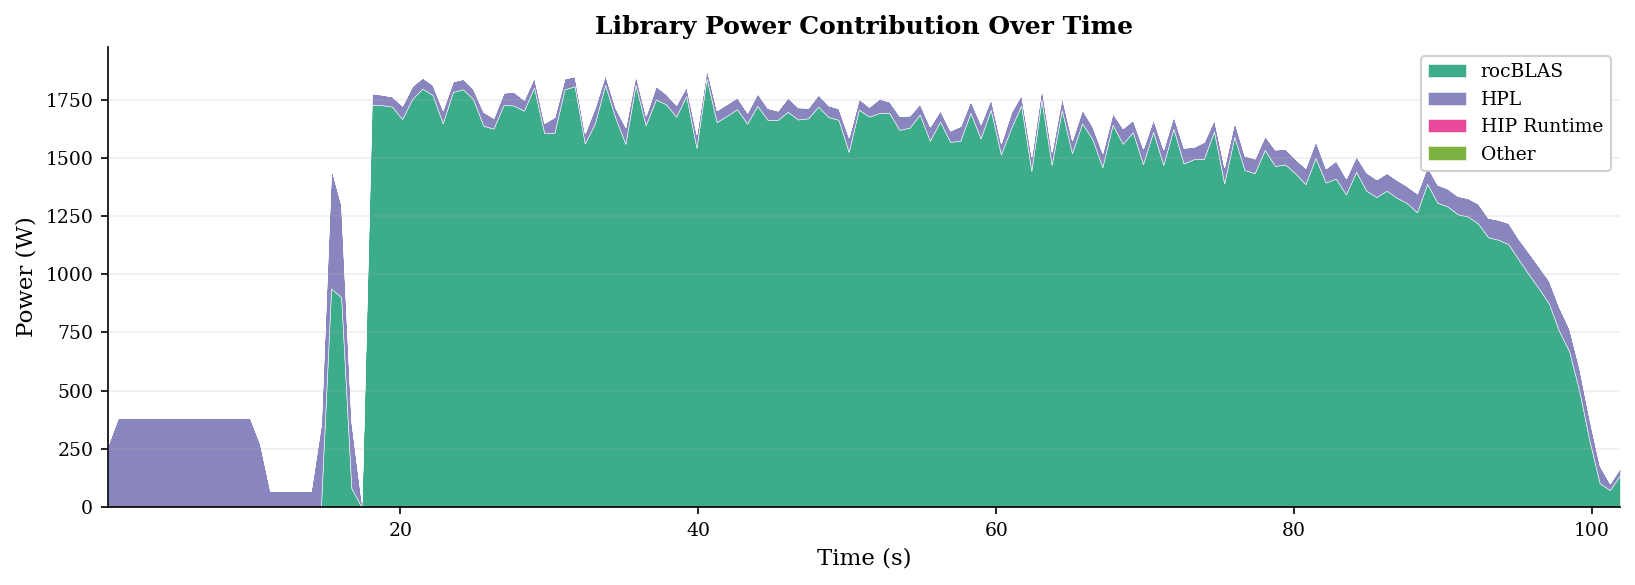

In [12]:
# ── Fig 8: Stacked area — Library power over time ────────────

N_BINS_AREA = 150
t_min_a = compute_power_sig['Start Time'].min()
t_max_a = compute_power_sig['End Time'].max()
bin_edges_a = np.linspace(t_min_a, t_max_a, N_BINS_AREA + 1)
bin_centers_a = 0.5 * (bin_edges_a[:-1] + bin_edges_a[1:])
bin_width_a = bin_edges_a[1] - bin_edges_a[0]

# Libraries to show (in stacking order)
area_libs = ['rocBLAS', 'HPL', 'rocSOLVER', 'HIP Runtime', 'Other']
area_libs = [l for l in area_libs if l in compute_energy.Library.unique()]

# For each library, compute energy deposited per time bin, then express as power
lib_power_timeline = {}
for lib in area_libs:
    sub = compute_energy[compute_energy['Library'] == lib]
    bins = np.zeros(N_BINS_AREA)
    for _, row in sub.iterrows():
        s, e, v = row['Start Time'], row['End Time'], row['Value']
        dur = e - s
        if dur <= 0:
            continue
        i0 = max(np.searchsorted(bin_edges_a, s, side='right') - 1, 0)
        i1 = min(np.searchsorted(bin_edges_a, e, side='left'), N_BINS_AREA)
        for bi in range(i0, i1):
            overlap = min(e, bin_edges_a[bi+1]) - max(s, bin_edges_a[bi])
            bins[bi] += v * (overlap / dur)
    # Convert to power (energy per bin / bin width)
    lib_power_timeline[lib] = bins / bin_width_a

fig, ax = plt.subplots(figsize=(11, 4))

stack_data = np.array([lib_power_timeline[l] for l in area_libs])
colors = [LIB_PALETTE[l] for l in area_libs]

ax.stackplot(bin_centers_a, stack_data, labels=area_libs, colors=colors, alpha=0.85,
             edgecolor='white', linewidth=0.3)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Power (W)')
ax.set_title('Library Power Contribution Over Time', fontweight='bold')
ax.legend(loc='upper right', frameon=True, framealpha=0.9)
ax.set_xlim(bin_centers_a[0], bin_centers_a[-1])
ax.set_ylim(bottom=0)
ax.grid(axis='y', alpha=0.2)

fig.tight_layout()
plt.savefig('fig8_stacked_area_power.pdf', bbox_inches='tight')
plt.show()

## Figure 9 — Violin + Box: Power Efficiency by Function

A violin-and-box composite for the top energy-consuming functions. The violin shows the full density of per-call power; the embedded box plot shows quartiles. This is a more rigorous alternative to the ridgeline plot, and works well for a smaller number of functions shown at higher detail.

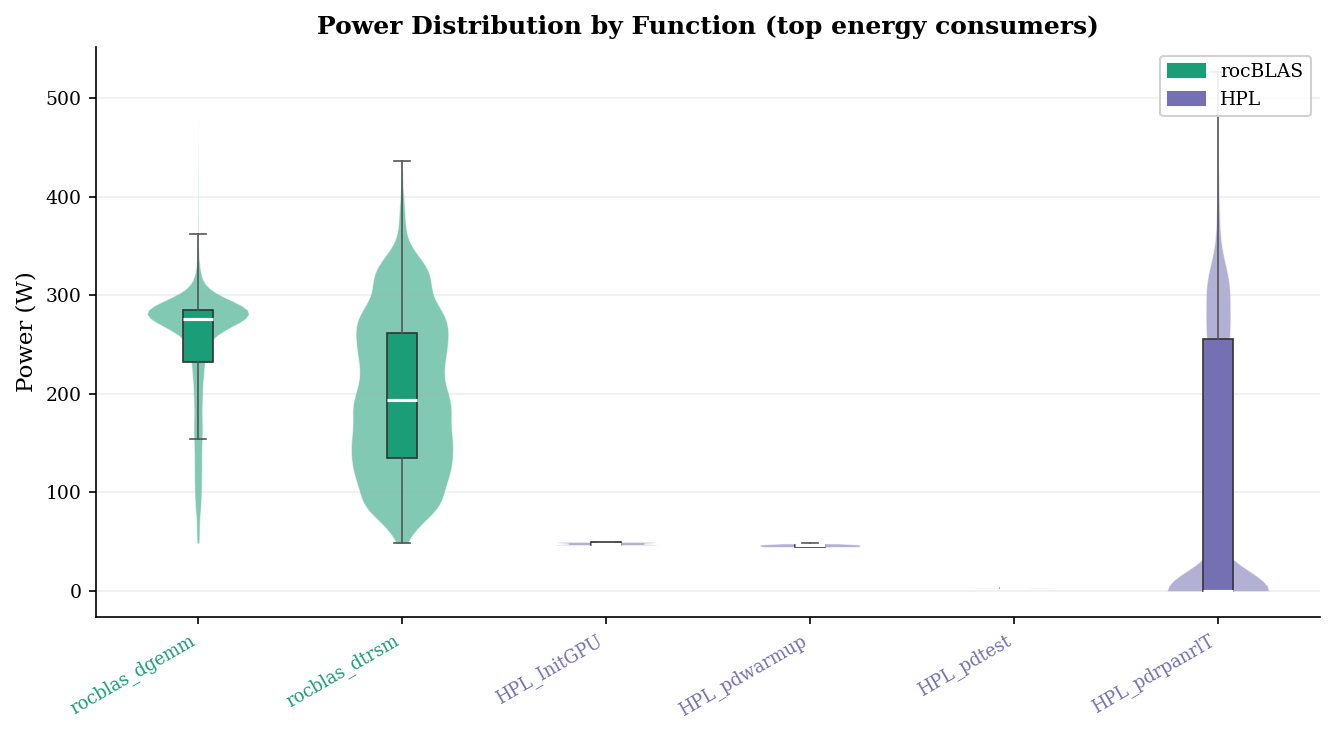

In [13]:
# ── Fig 9: Violin + box — Power distribution for top functions ──

top_funcs_violin = (compute_energy_sig.groupby('ShortName')['Value'].sum()
                    .sort_values(ascending=False).head(6).index.tolist())

violin_df = compute_power_sig[compute_power_sig['ShortName'].isin(top_funcs_violin)].copy()

# Order by median power
med_order = (violin_df.groupby('ShortName')['Value']
             .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(9, 5))

# Map libraries to colors for each function
func_lib_map = violin_df.groupby('ShortName')['Library'].first().to_dict()
palette = {f: LIB_PALETTE.get(func_lib_map.get(f, 'Other'), '#888') for f in med_order}

parts = ax.violinplot(
    [violin_df[violin_df['ShortName'] == f]['Value'].values for f in med_order],
    positions=range(len(med_order)),
    showmeans=False, showextrema=False, showmedians=False
)

for i, (pc, func) in enumerate(zip(parts['bodies'], med_order)):
    color = palette[func]
    pc.set_facecolor(color)
    pc.set_edgecolor('white')
    pc.set_linewidth(0.5)
    pc.set_alpha(0.55)

# Overlay box plots
bp = ax.boxplot(
    [violin_df[violin_df['ShortName'] == f]['Value'].values for f in med_order],
    positions=range(len(med_order)),
    widths=0.15, patch_artist=True,
    showfliers=False, zorder=3
)
for i, (patch, func) in enumerate(zip(bp['boxes'], med_order)):
    patch.set_facecolor(palette[func])
    patch.set_edgecolor('#333')
    patch.set_linewidth(0.8)
for element in ['whiskers', 'caps']:
    for line in bp[element]:
        line.set_color('#555')
        line.set_linewidth(0.8)
for line in bp['medians']:
    line.set_color('white')
    line.set_linewidth(1.5)

ax.set_xticks(range(len(med_order)))
ax.set_xticklabels(med_order, rotation=30, ha='right', fontsize=8.5)
# Color x-labels by library
for i, func in enumerate(med_order):
    ax.get_xticklabels()[i].set_color(palette[func])

ax.set_ylabel('Power (W)')
ax.set_title('Power Distribution by Function (top energy consumers)',
             fontweight='bold')
ax.grid(axis='y', alpha=0.2)

# Library legend
legend_libs = list(dict.fromkeys(func_lib_map[f] for f in med_order))  # unique, ordered
handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l) for l in legend_libs]
ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=0.9)

fig.tight_layout()
plt.savefig('fig9_violin_power.pdf', bbox_inches='tight')
plt.show()

## Figure 10 — Treemap: Hierarchical Energy Decomposition

A treemap where the area of each tile is proportional to energy consumed. The outer tiles are libraries; inner tiles are functions. This is the most information-dense single figure — it encodes the full hierarchy and magnitudes in one view.

In [14]:
# ── Fig 10: Treemap — Library → Function energy hierarchy ────
import squarify  # pip install squarify

# Aggregate energy per (library, function)
tree_data = (compute_energy.groupby(['Library', 'ShortName'])['Value']
             .sum().reset_index()
             .sort_values('Value', ascending=False))

# Keep top functions per library for readability
top_per_lib = tree_data.groupby('Library').head(5)
# Add "other" remainder per library
other_rows = []
for lib in tree_data['Library'].unique():
    all_val = tree_data[tree_data['Library'] == lib]['Value'].sum()
    top_val = top_per_lib[top_per_lib['Library'] == lib]['Value'].sum()
    remainder = all_val - top_val
    if remainder > 0:
        other_rows.append({'Library': lib, 'ShortName': f'(other)', 'Value': remainder})
tree_df = pd.concat([top_per_lib, pd.DataFrame(other_rows)], ignore_index=True)
tree_df = tree_df[tree_df['Value'] > 0].sort_values(['Library', 'Value'], ascending=[True, False])

# Build treemap data
labels, sizes, colors = [], [], []
for _, row in tree_df.iterrows():
    labels.append(row['ShortName'])
    sizes.append(row['Value'])
    base = LIB_PALETTE.get(row['Library'], '#888')
    # Slightly vary brightness per function within a library for visual distinction
    colors.append(base)

# Lighten alternating tiles within each library
color_final = []
lib_counter = {}
for _, row in tree_df.iterrows():
    lib = row['Library']
    lib_counter[lib] = lib_counter.get(lib, 0) + 1
    base = mcolors.to_rgb(LIB_PALETTE.get(lib, '#888'))
    factor = 0.12 * (lib_counter[lib] % 3)
    lightened = tuple(min(c + factor, 1.0) for c in base)
    color_final.append(lightened)

fig, ax = plt.subplots(figsize=(12, 7))
squarify.plot(sizes=sizes, label=None, color=color_final,
              alpha=0.88, edgecolor='white', linewidth=2, ax=ax)

# Add labels for larger tiles
rects = squarify.normalize_sizes(sizes, 100, 60)
rects = squarify.squarify(rects, 0, 0, 100, 60)
total_area = sum(sizes)
for rect, label, sz in zip(rects, labels, sizes):
    frac = sz / total_area
    if frac > 0.02:
        cx = rect['x'] + rect['dx'] / 2
        cy = rect['y'] + rect['dy'] / 2
        fontsize = max(6, min(11, frac * 120))
        ax.text(cx, cy, f'{label}\n{frac*100:.1f}%',
                ha='center', va='center', fontsize=fontsize,
                color='white' if frac > 0.05 else '#333',
                fontweight='bold' if frac > 0.05 else 'normal')

# Library legend
handles = [mpatches.Patch(color=LIB_PALETTE[l], label=l)
           for l in tree_df['Library'].unique()]
ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=0.9, fontsize=9)

ax.set_title('Energy Treemap: Library and Function Decomposition',
             fontweight='bold', fontsize=13)
ax.axis('off')

fig.tight_layout()
plt.savefig('fig10_treemap.pdf', bbox_inches='tight')
plt.show()

ModuleNotFoundError: No module named 'squarify'